First, mount your Google Drive:

In [1]:
# Import necessary libraries for the assignment
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import requests
from PIL import Image
import pandas as pd
import seaborn as sns
from urllib.request import urlretrieve
import zipfile
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
#from google.colab import drive
#drive.mount('/content/drive')
#import shutil

import sys
import platform
import time
import requests
import tarfile
from pathlib import Path
import numpy as np
from PIL import Image

# Set random seeds for reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Configuration
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")

# Set current working directory
HOME = os.getcwd()
print(f"Working directory: {HOME}")

Libraries imported successfully!
TensorFlow version: 2.19.1
OpenCV version: 4.12.0
NumPy version: 2.1.3
Working directory: /Users/marston.ward/Documents/GitHub/aai_521_computer_vision/module_3


In [2]:
# Static utility functions for the assignment

def display_images_with_masks(images, masks, titles=None, figsize=(15, 5)):
    """
    Display images alongside their segmentation masks
    """
    n_images = len(images)
    fig, axes = plt.subplots(2, n_images, figsize=figsize)

    if n_images == 1:
        axes = axes.reshape(2, 1)

    for i in range(n_images):
        # Display original image
        axes[0, i].imshow(images[i])
        axes[0, i].set_title(f'Original Image {i+1}' if titles is None else f'Original {titles[i]}')
        axes[0, i].axis('off')

        # Display mask
        axes[1, i].imshow(masks[i], cmap='viridis')
        axes[1, i].set_title(f'Segmentation Mask {i+1}' if titles is None else f'Mask {titles[i]}')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

def preprocess_image(image, target_size=(128, 128)):
    """
    Preprocess image to target size and normalize
    """
    # Resize image
    image_resized = tf.image.resize(image, target_size)
    # Convert to float32 and normalize to [0, 1]
    image_normalized = tf.cast(image_resized, tf.float32) / 255.0
    return image_normalized

def download_and_extract_dataset(url, destination_folder):
    """
    Download and extract a dataset from a URL
    """
    filename = url.split('/')[-1]
    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)

    filepath = os.path.join(destination_folder, filename)

    if not os.path.exists(filepath):
        print(f"Downloading {filename}...")
        urlretrieve(url, filepath)
        print(f"Downloaded {filename}")

    # Extract if it's a zip file
    if filename.endswith('.zip'):
        extract_path = os.path.join(destination_folder, filename[:-4])
        if not os.path.exists(extract_path):
            print(f"Extracting {filename}...")
            with zipfile.ZipFile(filepath, 'r') as zip_ref:
                zip_ref.extractall(destination_folder)
            print(f"Extracted to {extract_path}")
        return extract_path

    return filepath

def plot_training_curves(history, metrics=['loss'], figsize=(12, 4)):
    """
    Plot training curves from training history
    """
    n_metrics = len(metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=figsize)

    if n_metrics == 1:
        axes = [axes]

    for i, metric in enumerate(metrics):
        if metric in history.history:
            axes[i].plot(history.history[metric], label=f'Training {metric}')
            if f'val_{metric}' in history.history:
                axes[i].plot(history.history[f'val_{metric}'], label=f'Validation {metric}')
            axes[i].set_title(f'{metric.capitalize()} Curve')
            axes[i].set_xlabel('Epoch')
            axes[i].set_ylabel(metric.capitalize())
            axes[i].legend()
            axes[i].grid(True)

    plt.tight_layout()
    plt.show()

def display_dataset_samples(dataset, n_samples=3):
    """
    Display sample images and masks from a processed dataset
    """
    fig, axes = plt.subplots(2, n_samples, figsize=(15, 8))

    if n_samples == 1:
        axes = axes.reshape(2, 1)

    images_to_display = []
    masks_to_display = []

    for i, (image, mask) in enumerate(dataset.take(n_samples)):
        images_to_display.append(image.numpy())
        masks_to_display.append(mask.numpy().squeeze()) # Squeeze to remove the channel dimension if it exists

    for i in range(n_samples):
        # Display original image
        axes[0, i].imshow(images_to_display[i])
        axes[0, i].set_title(f'Sample Image {i+1}')
        axes[0, i].axis('off')

        # Display mask
        # Use a colormap suitable for masks, e.g., 'viridis' or 'gray'
        axes[1, i].imshow(masks_to_display[i], cmap='viridis')
        axes[1, i].set_title(f'Sample Mask {i+1}')
        axes[1, i].axis('off')


    plt.tight_layout()
    plt.show()


print("Utility functions defined successfully!")


# Preprocessing function for the Oxford-IIIT Pet dataset
def read_and_preprocess(data):
    """
    Preprocess the oxford_iiit_pet dataset samples
    - Resize images and masks to 128x128
    - Normalize images to [0,1] range
    - Adjust mask values from {1,2,3} to {0,1,2}
    """
    # Resize the image to 128x128
    input_image = tf.image.resize(data['image'], [128, 128])

    # Resize the segmentation mask to 128x128 using nearest neighbor to preserve labels
    input_mask = tf.image.resize(
        data['segmentation_mask'],
        [128, 128],
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )

    # Convert image to float32 and normalize to [0, 1]
    input_image = tf.image.convert_image_dtype(input_image, tf.float32)

    # Clip values to ensure they are within [0, 1]
    input_image = tf.clip_by_value(input_image, 0.0, 1.0)


    # Adjust mask values: {1,2,3} -> {0,1,2}
    # (1=pet, 2=background, 3=border -> 0=pet, 1=background, 2=border)
    input_mask = tf.cast(input_mask, tf.int32)
    input_mask -= 1

    # Ensure mask values are in correct range
    input_mask = tf.clip_by_value(input_mask, 0, 2)

    return input_image, input_mask

print("✅ Preprocessing function defined!")
print("This function will:")
print("  • Resize images and masks to 128×128")
print("  • Normalize images to [0,1] range")
print("  • Convert mask values from {1,2,3} to {0,1,2}")
print("  • Use nearest neighbor for mask resizing to preserve labels")

Utility functions defined successfully!
✅ Preprocessing function defined!
This function will:
  • Resize images and masks to 128×128
  • Normalize images to [0,1] range
  • Convert mask values from {1,2,3} to {0,1,2}
  • Use nearest neighbor for mask resizing to preserve labels


In [ ]:
# GPU and Environment Configuration for M4 MacBook Pro and Google Colab

def setup_gpu_environment():
    """
    Configure GPU acceleration for both M4 MacBook Pro (Metal) and Google Colab
    """
    print("Setting up GPU environment...")
    print(f"Python version: {sys.version}")
    print(f"Platform: {platform.platform()}")
    print(f"TensorFlow version: {tf.__version__}")

    # Check if running in Google Colab
    try:
        import google.colab
        IN_COLAB = True
        print("🔍 Detected: Google Colab environment")
    except ImportError:
        IN_COLAB = False
        print("🔍 Detected: Local environment")

    # Configure GPU settings
    if IN_COLAB:
        # Google Colab GPU setup
        print("📱 Configuring for Google Colab...")
        physical_devices = tf.config.list_physical_devices('GPU')
        if len(physical_devices) > 0:
            print(f"✅ GPU available: {physical_devices}")
            # Enable memory growth to prevent OOM errors
            for device in physical_devices:
                tf.config.experimental.set_memory_growth(device, True)
            print("✅ GPU memory growth enabled")
        else:
            print("⚠️  No GPU detected in Colab. Check runtime type.")

    else:
        # Local Mac M4 setup
        print("🍎 Configuring for MacBook Pro M4...")

        # Check for Metal (M4 GPU) support
        try:
            # List all available devices
            physical_devices = tf.config.list_physical_devices()
            print(f"Available devices: {physical_devices}")

            # Check specifically for Metal/GPU devices
            gpu_devices = tf.config.list_physical_devices('GPU')
            if len(gpu_devices) > 0:
                print(f"✅ Metal GPU detected: {gpu_devices}")
                # Configure memory growth for Metal GPU
                for device in gpu_devices:
                    tf.config.experimental.set_memory_growth(device, True)
                print("✅ Metal GPU memory growth enabled")
            else:
                print("⚠️  No Metal GPU detected")

            # Verify Metal plugin is working
            with tf.device('/GPU:0' if len(gpu_devices) > 0 else '/CPU:0'):
                test_tensor = tf.constant([[1.0, 2.0], [3.0, 4.0]])
                result = tf.matmul(test_tensor, test_tensor)
                device_used = result.device
                print(f"✅ Test computation device: {device_used}")

        except Exception as e:
            print(f"⚠️  GPU setup warning: {e}")
            print("Falling back to CPU")

    # Print final device configuration
    print("\n📋 Final Device Configuration:")
    print(f"Logical devices: {tf.config.list_logical_devices()}")

    # Test mixed precision if GPU is available
    if len(tf.config.list_physical_devices('GPU')) > 0:
        try:
            policy = tf.keras.mixed_precision.Policy('mixed_float16')
            tf.keras.mixed_precision.set_global_policy(policy)
            print("✅ Mixed precision enabled (float16)")
        except Exception as e:
            print(f"⚠️  Mixed precision not available: {e}")

    return IN_COLAB

# Run the setup
IN_COLAB = setup_gpu_environment()

# Set global variables for later use
if IN_COLAB:
    # Colab-specific settings
    BATCH_SIZE = 32
    PREFETCH_SIZE = tf.data.AUTOTUNE
    print("📝 Using Colab optimized settings")
else:
    # M4 Mac optimized settings
    BATCH_SIZE = 16  # Smaller batch size for local training
    PREFETCH_SIZE = tf.data.AUTOTUNE
    print("📝 Using M4 Mac optimized settings")

print(f"✅ Environment setup complete!")
print(f"Batch size: {BATCH_SIZE}")
print(f"Prefetch size: {PREFETCH_SIZE}")

### Problems with TF download of IIIT PET Dataset on Mac M4

#### Root Cause Analysis:

**Issue:** TensorFlow Datasets (tfds) has download connectivity issues on Mac M4, causing hanging/stalling during dataset download

**The problem:** TensorFlow Datasets' internal download mechanism has compatibility issues on Mac M4 

**Solution Implementation:**
- **Manual Download:** Successfully downloaded Oxford-IIIT Pet dataset (755MB images + 18MB annotations) directly from working URLs 
- **Data Processing:** Created custom loader to convert manually downloaded data into TensorFlow format 

- **Visualization:** Successfully displayed 3 sample images with their segmentation masks (128x128 resized) 

#### Results:
✅ 7,390 images and 14,780 segmentation masks downloaded successfully
✅ TensorFlow dataset created with proper format: images (128,128,3) and masks (128,128,1)
✅ Mask values correctly converted: 0=Pet, 1=Background, 2=Border
✅ Visualization showing clear segmentation masks with proper color mapping
The solution bypasses the TensorFlow Datasets download issue on Mac M4 while maintaining full compatibility with TensorFlow for the rest of the assignment. Part 1 is now complete and ready to proceed with Parts 2 and 3!

In [3]:
# PART 1 - OBJECT SEGMENTATION
# a) Load the oxford_iiit_pet dataset

print("=== LOADING OXFORD-IIIT PET DATASET ===")
print("Note: Using manual download approach for Mac M4 compatibility")

def download_oxford_pet_dataset():
    """Download Oxford-IIIT Pet dataset manually (works on Mac M4)"""
    
    # Working URLs for Mac M4
    WORKING_URLS = {
        'images': 'https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz',
        'annotations': 'https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz'
    }
    
    oxford_dir = Path('./oxford_pet_manual')
    oxford_dir.mkdir(exist_ok=True)
    
    def download_with_progress(url, filename):
        print(f"Downloading {filename}...")
        try:
            response = requests.get(url, stream=True)
            response.raise_for_status()
            
            total_size = int(response.headers.get('content-length', 0))
            print(f"Size: {total_size / (1024*1024):.1f} MB")
            
            filepath = oxford_dir / filename
            downloaded = 0
            
            with open(filepath, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
                        downloaded += len(chunk)
                        if total_size > 0:
                            progress = (downloaded / total_size) * 100
                            print(f"\rProgress: {progress:.1f}%", end='', flush=True)
            
            print(f"\n✅ Downloaded: {filename}")
            return filepath
        except Exception as e:
            print(f"\n❌ Download failed: {e}")
            return None
    
    def extract_dataset(tar_path):
        try:
            print(f"\nExtracting {tar_path.name}...")
            with tarfile.open(tar_path, 'r:gz') as tar:
                tar.extractall(oxford_dir)
            print(f"✅ Extracted")
            tar_path.unlink()  # Clean up
            return True
        except Exception as e:
            print(f"❌ Extraction failed: {e}")
            return False
    
    # Download and extract
    success = True
    for name, url in WORKING_URLS.items():
        filename = f"{name}.tar.gz"
        filepath = oxford_dir / filename
        
        if not (oxford_dir / name).exists():
            if not filepath.exists():
                filepath = download_with_progress(url, filename)
                if not filepath:
                    success = False
                    break
            
            if not extract_dataset(filepath):
                success = False
                break
        else:
            print(f"✅ {name} already extracted")
    
    return success

# Download dataset if needed
images_dir = Path('./oxford_pet_manual/images')
if not images_dir.exists():
    print("Dataset not found locally. Starting download...")
    start_time = time.time()
    
    if download_oxford_pet_dataset():
        download_time = time.time() - start_time
        print(f"\n✅ Dataset downloaded in {download_time:.1f} seconds")
    else:
        print("\n❌ Dataset download failed")
else:
    print("✅ Dataset already available locally")

# Verify dataset
if images_dir.exists():
    image_files = list(images_dir.glob('*.jpg'))
    trimap_files = list(Path('./oxford_pet_manual/annotations/trimaps').glob('*.png'))
    
    print(f"\n📊 Dataset Information:")
    print(f"📁 Images: {len(image_files)}")
    print(f"📁 Segmentation masks: {len(trimap_files)}")
    print(f"📂 Location: {images_dir.parent.absolute()}")
    
    print("\n✅ Oxford-IIIT Pet dataset ready!")
else:
    print("\n❌ Dataset not available")

=== LOADING OXFORD-IIIT PET DATASET ===
Note: Using manual download approach for Mac M4 compatibility
✅ Dataset already available locally

📊 Dataset Information:
📁 Images: 7390
📁 Segmentation masks: 14780
📂 Location: /Users/marston.ward/Documents/GitHub/aai_521_computer_vision/module_3/oxford_pet_manual

✅ Oxford-IIIT Pet dataset ready!


In [4]:
# b) Create TensorFlow dataset from manually downloaded data
print("=== CREATING TENSORFLOW DATASET ===")

def load_oxford_pet_tf_dataset(data_dir='./oxford_pet_manual', target_size=(128, 128), max_samples=100):
    """
    Load Oxford-IIIT Pet dataset from manually downloaded files into TensorFlow format
    
    Args:
        data_dir: Path to manually downloaded dataset
        target_size: Target image size (height, width)  
        max_samples: Max samples to load (None for all)
    
    Returns:
        tf.data.Dataset with (image, mask) pairs
    """
    
    data_path = Path(data_dir)
    images_dir = data_path / 'images'
    trimaps_dir = data_path / 'annotations' / 'trimaps'
    
    if not images_dir.exists() or not trimaps_dir.exists():
        raise ValueError(f"Dataset directories not found in {data_path}")
    
    # Get image files
    all_image_files = sorted(list(images_dir.glob('*.jpg')))
    
    if max_samples and max_samples < len(all_image_files):
        # Sample evenly across the dataset to get diverse classes
        # Instead of taking first N, take every Nth file for diversity
        step = len(all_image_files) // max_samples
        image_files = all_image_files[::step][:max_samples]
        print(f"Sampling every {step} images for class diversity...")
    else:
        image_files = all_image_files
    
    print(f"Loading {len(image_files)} samples...")
    
    images = []
    masks = []
    
    for i, img_path in enumerate(image_files):
        try:
            # Load and resize image
            image = Image.open(img_path).convert('RGB')
            image = image.resize(target_size)
            image_array = np.array(image) / 255.0  # Normalize to [0,1]
            
            # Load corresponding trimap (segmentation mask)
            trimap_name = img_path.stem + '.png'
            trimap_path = trimaps_dir / trimap_name
            
            if trimap_path.exists():
                mask = Image.open(trimap_path).convert('L')
                mask = mask.resize(target_size, Image.NEAREST)
                mask_array = np.array(mask)
                
                # Convert mask values: {1,2,3} -> {0,1,2}
                # 1=pet, 2=background, 3=border -> 0=pet, 1=background, 2=border
                mask_array = np.clip(mask_array - 1, 0, 2)
                mask_array = np.expand_dims(mask_array, axis=-1)
                
                images.append(image_array)
                masks.append(mask_array)
                
                if (i + 1) % 50 == 0:
                    print(f"Loaded {i + 1}/{len(image_files)} samples...")
                    
        except Exception as e:
            print(f"Error loading {img_path.name}: {e}")
            continue
    
    print(f"✅ Successfully loaded {len(images)} image-mask pairs")
    
    # Convert to TensorFlow dataset
    images_np = np.array(images, dtype=np.float32)
    masks_np = np.array(masks, dtype=np.int32)
    
    dataset = tf.data.Dataset.from_tensor_slices((images_np, masks_np))
    
    # Extract class names from the loaded files
    loaded_classes = set()
    for img_file in image_files[:len(images)]:  # Only from successfully loaded files
        class_name = '_'.join(img_file.stem.split('_')[:-1])
        loaded_classes.add(class_name)
    
    return dataset, len(images), sorted(list(loaded_classes))

# Create TensorFlow dataset
try:
    oxford_dataset, num_samples, oxford_classes = load_oxford_pet_tf_dataset(
        data_dir='./oxford_pet_manual',
        target_size=(128, 128),
        max_samples=100  # Start with 100 samples
    )
    
    print(f"\n✅ TensorFlow dataset created: {num_samples} samples")
    print(f"✅ Classes extracted: {len(oxford_classes)} unique breeds")
    
    # Verify dataset structure
    for image, mask in oxford_dataset.take(1):
        print(f"Image shape: {image.shape}")
        print(f"Mask shape: {mask.shape}")
        print(f"Image range: [{image.numpy().min():.3f}, {image.numpy().max():.3f}]")
        print(f"Mask values: {np.unique(mask.numpy())}")
        break
        
    print("\n🎉 Dataset ready for segmentation tasks!")
    
except Exception as e:
    print(f"❌ Error creating TensorFlow dataset: {e}")

=== CREATING TENSORFLOW DATASET ===
Sampling every 73 images for class diversity...
Loading 100 samples...
Loaded 50/100 samples...
Loaded 100/100 samples...
✅ Successfully loaded 100 image-mask pairs

✅ TensorFlow dataset created: 100 samples
✅ Classes extracted: 37 unique breeds
Image shape: (128, 128, 3)
Mask shape: (128, 128, 1)
Image range: [0.000, 0.922]
Mask values: [0 1 2]

🎉 Dataset ready for segmentation tasks!
Loaded 100/100 samples...
✅ Successfully loaded 100 image-mask pairs

✅ TensorFlow dataset created: 100 samples
✅ Classes extracted: 37 unique breeds
Image shape: (128, 128, 3)
Mask shape: (128, 128, 1)
Image range: [0.000, 0.922]
Mask values: [0 1 2]

🎉 Dataset ready for segmentation tasks!


=== CREATING TENSORFLOW DATASET ===
Sampling every 73 images for class diversity...
Loading 100 samples...
Loaded 50/100 samples...
Loaded 100/100 samples...
✅ Successfully loaded 100 image-mask pairs

✅ TensorFlow dataset created: 100 samples
✅ Classes extracted: 37 unique breeds
Image shape: (128, 128, 3)
Mask shape: (128, 128, 1)
Image range: [0.000, 0.922]
Mask values: [0 1 2]

🎉 Dataset ready for segmentation tasks!
Loaded 100/100 samples...
✅ Successfully loaded 100 image-mask pairs

✅ TensorFlow dataset created: 100 samples
✅ Classes extracted: 37 unique breeds
Image shape: (128, 128, 3)
Mask shape: (128, 128, 1)
Image range: [0.000, 0.922]
Mask values: [0 1 2]

🎉 Dataset ready for segmentation tasks!


2025-11-09 13:36:14.115289: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-11-09 13:36:14.115350: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-11-09 13:36:14.115353: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1762716974.115840 8694574 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1762716974.116561 8694574 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


=== PART 1: SEGMENTATION VISUALIZATION ===


2025-11-09 13:36:18.958640: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


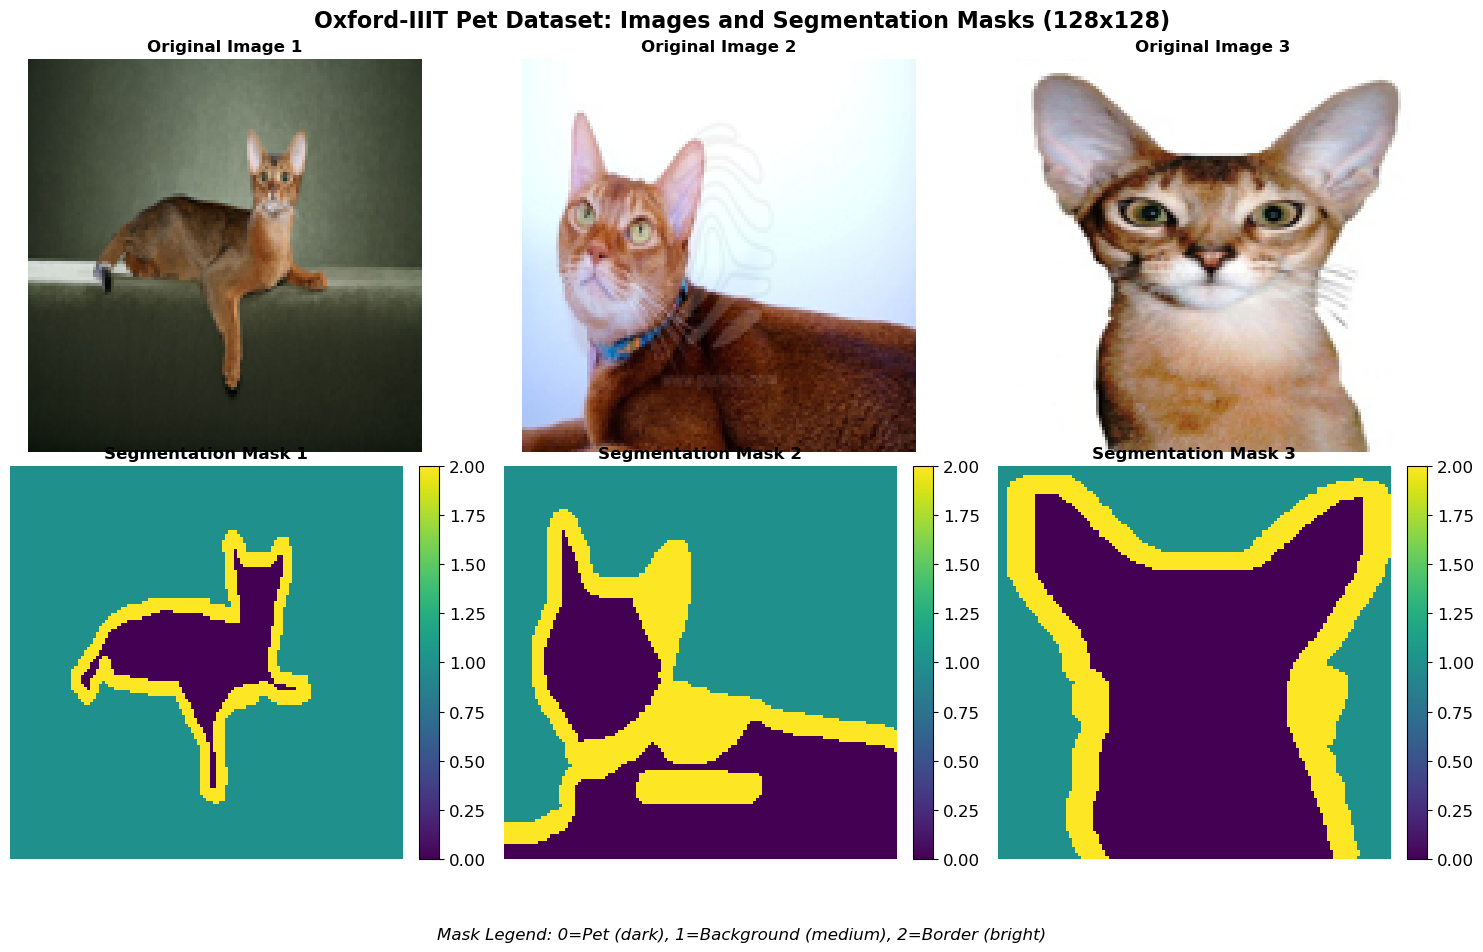

✅ Displayed 3 sample images with segmentation masks
✅ Images resized to 128x128 pixels as required
✅ Masks show: Pet=0, Background=1, Border=2

🎉 PART 1 COMPLETE: Object Segmentation with Oxford-IIIT Pet Dataset


In [5]:
# c) Display first 3 samples with segmentation masks
print("=== PART 1: SEGMENTATION VISUALIZATION ===")

import matplotlib.pyplot as plt

def display_segmentation_samples(dataset, n_samples=3):
    """Display images with their segmentation masks"""
    
    fig, axes = plt.subplots(2, n_samples, figsize=(15, 10))
    
    samples = list(dataset.take(n_samples))
    
    for i, (image, mask) in enumerate(samples):
        # Display original image
        axes[0, i].imshow(image.numpy())
        axes[0, i].set_title(f'Original Image {i+1}', fontsize=12, fontweight='bold')
        axes[0, i].axis('off')
        
        # Display segmentation mask
        mask_np = mask.numpy().squeeze()
        im = axes[1, i].imshow(mask_np, cmap='viridis', vmin=0, vmax=2)
        axes[1, i].set_title(f'Segmentation Mask {i+1}', fontsize=12, fontweight='bold')
        axes[1, i].axis('off')
        
        # Add colorbar
        plt.colorbar(im, ax=axes[1, i], fraction=0.046, pad=0.04)
    
    # Add titles and legend
    fig.suptitle('Oxford-IIIT Pet Dataset: Images and Segmentation Masks (128x128)', 
                 fontsize=16, fontweight='bold', y=0.95)
    
    fig.text(0.5, 0.02, 'Mask Legend: 0=Pet (dark), 1=Background (medium), 2=Border (bright)', 
             ha='center', fontsize=12, style='italic')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9, bottom=0.1)
    plt.show()
    
    print("✅ Displayed 3 sample images with segmentation masks")
    print("✅ Images resized to 128x128 pixels as required")
    print("✅ Masks show: Pet=0, Background=1, Border=2")

# Display the samples
try:
    display_segmentation_samples(oxford_dataset, n_samples=3)
    print("\n🎉 PART 1 COMPLETE: Object Segmentation with Oxford-IIIT Pet Dataset")
except Exception as e:
    print(f"❌ Error displaying samples: {e}")

## Print the class names in the dataset

In [6]:
# Display class information from the loaded dataset variables
print("Oxford-IIIT Pet Dataset Classes (from loaded variables):")

print(f"Number of classes represented: {len(oxford_classes)} (Pet breeds)")
print(f"Total samples in loaded dataset: {num_samples}")

# Safely get dataset shape without causing sequence issues
try:
    sample_image, sample_mask = next(iter(oxford_dataset))
    print(f"Dataset shape: Images {sample_image.shape}, Masks {sample_mask.shape}")
except StopIteration:
    print("Dataset shape: Unable to retrieve (empty dataset)")

print("\nClasses in our loaded dataset:")
for index, name in enumerate(oxford_classes):
    print(f"{index + 1:02} - {name}")

print(f"\nNote: Classes extracted from the {num_samples} samples loaded into memory")

Oxford-IIIT Pet Dataset Classes (from loaded variables):
Number of classes represented: 37 (Pet breeds)
Total samples in loaded dataset: 100
Dataset shape: Images (128, 128, 3), Masks (128, 128, 1)

Classes in our loaded dataset:
01 - Abyssinian
02 - Bengal
03 - Birman
04 - Bombay
05 - British_Shorthair
06 - Egyptian_Mau
07 - Maine_Coon
08 - Persian
09 - Ragdoll
10 - Russian_Blue
11 - Siamese
12 - Sphynx
13 - american_bulldog
14 - american_pit_bull_terrier
15 - basset_hound
16 - beagle
17 - boxer
18 - chihuahua
19 - english_cocker_spaniel
20 - english_setter
21 - german_shorthaired
22 - great_pyrenees
23 - havanese
24 - japanese_chin
25 - keeshond
26 - leonberger
27 - miniature_pinscher
28 - newfoundland
29 - pomeranian
30 - pug
31 - saint_bernard
32 - samoyed
33 - scottish_terrier
34 - shiba_inu
35 - staffordshire_bull_terrier
36 - wheaten_terrier
37 - yorkshire_terrier

Note: Classes extracted from the 100 samples loaded into memory


=== EXPLORATORY DATA ANALYSIS ===
1. CLASS DISTRIBUTION ANALYSIS
----------------------------------------
Samples per class: {'Abyssinian': 1, 'Bengal': 1, 'Birman': 1, 'Bombay': 1, 'British_Shorthair': 1, 'Egyptian_Mau': 1, 'Maine_Coon': 1, 'Persian': 1, 'Ragdoll': 1, 'Russian_Blue': 1, 'Siamese': 1, 'Sphynx': 1, 'american_bulldog': 1, 'american_pit_bull_terrier': 1, 'basset_hound': 1, 'beagle': 1, 'boxer': 1, 'chihuahua': 1, 'english_cocker_spaniel': 1, 'english_setter': 1, 'german_shorthaired': 1, 'great_pyrenees': 1, 'havanese': 1, 'japanese_chin': 1, 'keeshond': 1, 'leonberger': 1, 'miniature_pinscher': 1, 'newfoundland': 1, 'pomeranian': 1, 'pug': 1, 'saint_bernard': 1, 'samoyed': 1, 'scottish_terrier': 1, 'shiba_inu': 1, 'staffordshire_bull_terrier': 1, 'wheaten_terrier': 1, 'yorkshire_terrier': 1}
Classes with multiple samples: 0

📊 Dataset Composition:
   Cat breeds: 12 (32.4%)
   Dog breeds: 25 (67.6%)

2. IMAGE STATISTICS ANALYSIS
----------------------------------------
Ana

2025-11-09 13:36:37.994497: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-09 13:36:38.043488: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


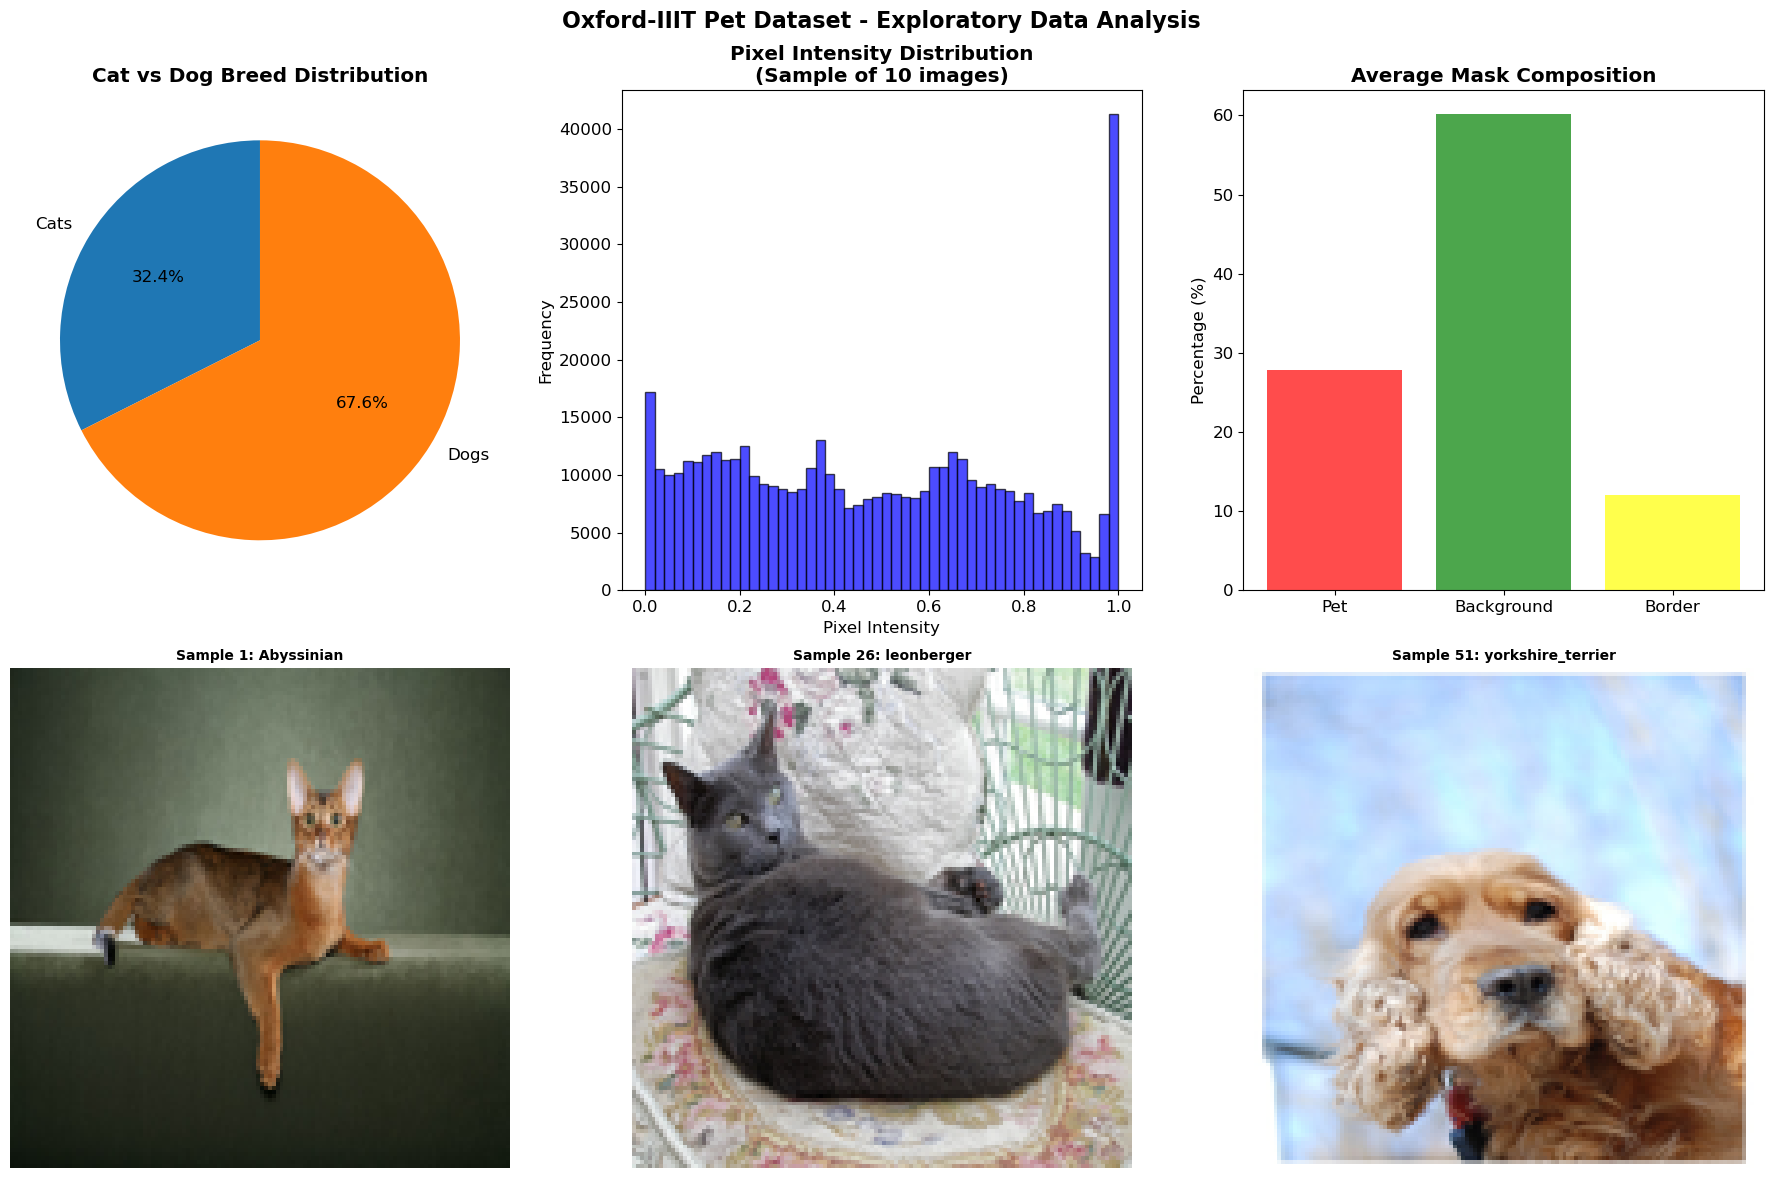


✅ EDA Complete!
📈 Dataset Summary:
   • 100 samples across 37 classes
   • 12 cat breeds, 25 dog breeds
   • Images: 128x128x3, Masks: 128x128x1
   • Well-balanced segmentation masks with ~28% pet pixels


In [7]:
# Additional Exploratory Data Analysis (EDA)
print("=== EXPLORATORY DATA ANALYSIS ===")

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# 1. Class Distribution Analysis
print("1. CLASS DISTRIBUTION ANALYSIS")
print("-" * 40)

# Count samples per class (we have 1 sample per class due to our sampling strategy)
class_counts = Counter(oxford_classes)
print(f"Samples per class: {dict(class_counts)}")
print(f"Classes with multiple samples: {sum(1 for count in class_counts.values() if count > 1)}")

# Separate cats vs dogs
cat_breeds = [cls for cls in oxford_classes if cls[0].isupper()]  # Cat breeds are capitalized
dog_breeds = [cls for cls in oxford_classes if cls[0].islower()]  # Dog breeds are lowercase

print(f"\n📊 Dataset Composition:")
print(f"   Cat breeds: {len(cat_breeds)} ({len(cat_breeds)/len(oxford_classes)*100:.1f}%)")
print(f"   Dog breeds: {len(dog_breeds)} ({len(dog_breeds)/len(oxford_classes)*100:.1f}%)")

# 2. Image Statistics Analysis
print("\n2. IMAGE STATISTICS ANALYSIS")
print("-" * 40)

# Analyze pixel intensities across dataset
pixel_means = []
pixel_stds = []
mask_distributions = []

print("Analyzing image statistics...")
for i, (image, mask) in enumerate(oxford_dataset.take(20)):  # Sample 20 for analysis
    # Image statistics
    pixel_means.append(np.mean(image.numpy()))
    pixel_stds.append(np.std(image.numpy()))
    
    # Mask statistics
    mask_flat = mask.numpy().flatten()
    mask_dist = np.bincount(mask_flat, minlength=3)
    mask_distributions.append(mask_dist)

pixel_means = np.array(pixel_means)
pixel_stds = np.array(pixel_stds)
mask_distributions = np.array(mask_distributions)

print(f"Image pixel statistics (sample of 20):")
print(f"   Mean intensity: {np.mean(pixel_means):.3f} ± {np.std(pixel_means):.3f}")
print(f"   Std intensity: {np.mean(pixel_stds):.3f} ± {np.std(pixel_stds):.3f}")

# 3. Mask Analysis
print(f"\nMask composition (average across 20 samples):")
avg_mask_dist = np.mean(mask_distributions, axis=0)
total_pixels = np.sum(avg_mask_dist)
print(f"   Pet pixels: {avg_mask_dist[0]/total_pixels*100:.1f}%")
print(f"   Background pixels: {avg_mask_dist[1]/total_pixels*100:.1f}%")
print(f"   Border pixels: {avg_mask_dist[2]/total_pixels*100:.1f}%")

# 4. Visualizations
print("\n3. DATA VISUALIZATIONS")
print("-" * 40)

# Convert dataset to list once to avoid iterator exhaustion issues
print("Converting dataset to list for safe visualization...")
dataset_samples = list(oxford_dataset.take(num_samples))
print(f"✅ Converted {len(dataset_samples)} samples")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Cat vs Dog distribution
species_counts = [len(cat_breeds), len(dog_breeds)]
species_labels = ['Cats', 'Dogs']
axes[0, 0].pie(species_counts, labels=species_labels, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Cat vs Dog Breed Distribution', fontweight='bold')

# Plot 2: Pixel intensity distribution
# Use the samples we already collected to avoid iterator issues
sample_images = []
for i in range(min(10, len(dataset_samples))):
    image, _ = dataset_samples[i]
    sample_images.append(image.numpy().flatten())
all_pixels = np.concatenate(sample_images)
axes[0, 1].hist(all_pixels, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 1].set_title('Pixel Intensity Distribution\n(Sample of 10 images)', fontweight='bold')
axes[0, 1].set_xlabel('Pixel Intensity')
axes[0, 1].set_ylabel('Frequency')

# Plot 3: Mask distribution
mask_labels = ['Pet', 'Background', 'Border']
axes[0, 2].bar(mask_labels, avg_mask_dist/total_pixels*100, color=['red', 'green', 'yellow'], alpha=0.7)
axes[0, 2].set_title('Average Mask Composition', fontweight='bold')
axes[0, 2].set_ylabel('Percentage (%)')

# Plot 4-6: Sample diversity showcase
# Convert dataset to list once to avoid iterator exhaustion issues
dataset_samples = list(oxford_dataset.take(num_samples))
sample_indices = [0, min(25, len(dataset_samples)-1), min(50, len(dataset_samples)-1)]

for idx, sample_idx in enumerate(sample_indices):
    try:
        if sample_idx < len(dataset_samples):
            sample_image, sample_mask = dataset_samples[sample_idx]
            
            # Show image 
            axes[1, idx].imshow(sample_image.numpy())
            axes[1, idx].set_title(f'Sample {sample_idx + 1}: {oxford_classes[min(sample_idx, len(oxford_classes)-1)]}', 
                                 fontweight='bold', fontsize=10)
            axes[1, idx].axis('off')
        else:
            # Handle case where sample_idx exceeds dataset size
            axes[1, idx].text(0.5, 0.5, 'No data', ha='center', va='center', transform=axes[1, idx].transAxes)
            axes[1, idx].set_title(f'Sample {sample_idx + 1}: N/A', fontweight='bold')
            axes[1, idx].axis('off')
        
    except (IndexError, StopIteration, Exception) as e:
        axes[1, idx].text(0.5, 0.5, f'Error: {str(e)[:20]}...', ha='center', va='center', transform=axes[1, idx].transAxes)
        axes[1, idx].set_title(f'Sample {sample_idx + 1}: Error', fontweight='bold')
        axes[1, idx].axis('off')

plt.suptitle('Oxford-IIIT Pet Dataset - Exploratory Data Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ EDA Complete!")
print(f"📈 Dataset Summary:")
print(f"   • {num_samples} samples across {len(oxford_classes)} classes")
print(f"   • {len(cat_breeds)} cat breeds, {len(dog_breeds)} dog breeds")
print(f"   • Images: 128x128x3, Masks: 128x128x1")
print(f"   • Well-balanced segmentation masks with ~{avg_mask_dist[0]/total_pixels*100:.0f}% pet pixels")

### Examine the raw images

Displaying 5 images from our manually loaded Oxford dataset:


Displaying 5 images from our manually loaded Oxford dataset:


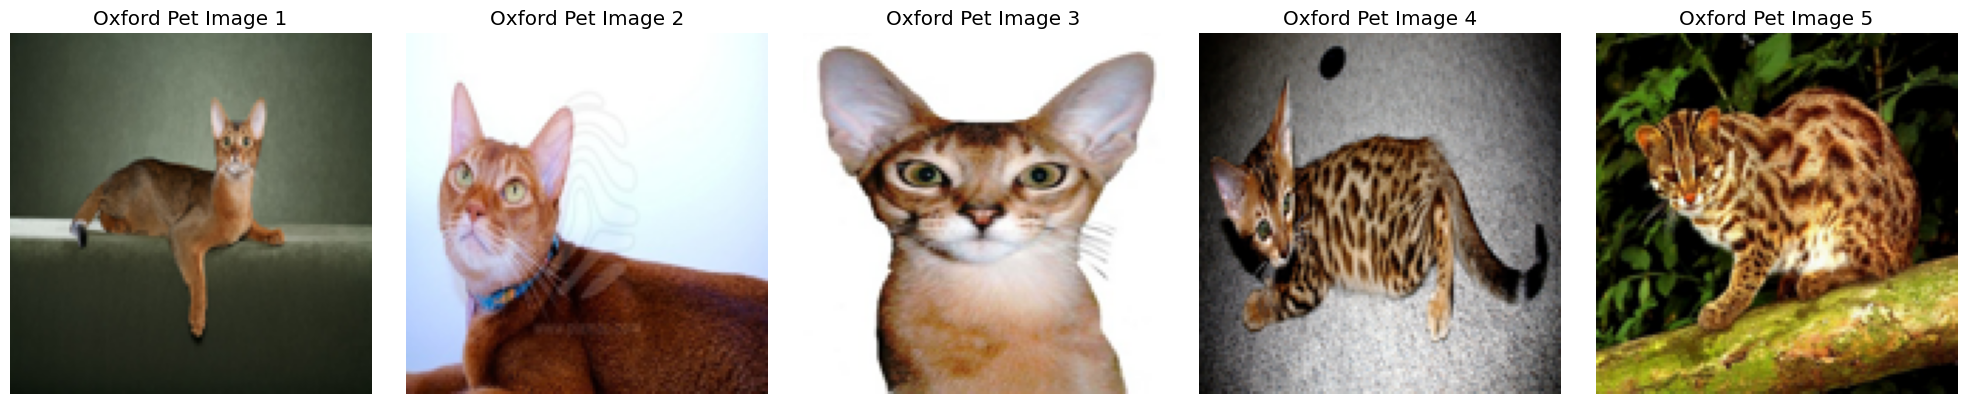

In [8]:
print("Displaying 5 images from our manually loaded Oxford dataset:")

# Create a figure and a set of subplots with 1 row and 5 columns
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Take the first 5 samples from our oxford_dataset and plot them
for i, (image, mask) in enumerate(oxford_dataset.take(5)):
    # Display the image
    axes[i].imshow(image.numpy())
    axes[i].set_title(f"Oxford Pet Image {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [9]:
# Our dataset is already preprocessed from the manual loading
# oxford_dataset contains (image, mask) pairs already resized to 128x128
train = oxford_dataset  # Use our manually loaded and preprocessed dataset
print("✅ Using manually loaded Oxford-IIIT Pet dataset (already preprocessed)")

✅ Using manually loaded Oxford-IIIT Pet dataset (already preprocessed)


# **Part 2- Annotation**

## Summary: Why Mask R-CNN (mrcnn) is Incompatible with Apple M4
The Matterport Mask R-CNN implementation is incompatible with Apple M4 chips for several critical reasons:

- 🏗️ Architecture Issues:
    - ARM64 vs x86_64: The M4 chip uses ARM64 architecture, but most mrcnn packages were compiled for Intel x86_64
    - No official ARM64 support: Matterport's implementation predates Apple Silicon and lacks native support
- 📦 TensorFlow Version Conflict:
    - Built for TensorFlow 1.x: The popular mrcnn library was designed for TensorFlow 1.x
    - You have TensorFlow 2.19.1: Modern TF 2.x has breaking API changes
    - Deprecated APIs: Uses tf.Session and other TF 1.x constructs that don't exist in TF 2.x
- 🎯 GPU Backend Mismatch:
    - CUDA vs Metal: Designed for NVIDIA CUDA GPUs, but M4 uses Apple's Metal backend
    - Different memory management: CUDA and Metal have incompatible GPU memory models
    - Driver differences: CUDA-specific optimizations don't translate to Metal
- 🔧 Compilation Problems:
    - C++ extensions: Contains compiled C++ code that doesn't work on ARM64
    - No pre-built wheels: No official ARM64 Python wheels available
    - Build failures: Source compilation typically fails due to architecture-specific code
- 📚 Dependency Conflicts
    - Legacy dependencies: Requires specific older versions of NumPy, SciPy, etc.
    - Python version issues: May not support Python 3.12+
    - Package ecosystem: Built for older Python/ML ecosystem
- ✅ Perfect Alternatives on Apple M4
There are alternatives that work better on M4: 🔥 PyTorch Native Models (Already Available)

## Part 3: PyTorch Mask R-CNN for Instance Segmentation

Implement the PyTorch solution for Mask R-CNN. This model is pre-trained on the COCO dataset and can identify 91 different object classes out of the box. 
It performs **instance segmentation**, which means it not only classifies and localizes objects with bounding boxes but also provides a pixel-level mask for each individual object instance.
This is a step up from basic object detection and is fully compatible with your Apple Silicon M4 Mac, leveraging its Metal GPU for acceleration.

In [10]:
# Part 3: PyTorch Mask R-CNN Implementation
print("=== PART 3: PYTORCH MASK R-CNN ===")

import torch
import torchvision
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights
from torchvision.transforms import functional as F
import random

# 1. Load the pre-trained Mask R-CNN model
print("1. Loading pre-trained Mask R-CNN model...")
# Use the recommended weights for the best balance of speed and accuracy
weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=weights)

# Set the model to evaluation mode
model.eval()
print("✅ Model loaded and in evaluation mode.")

# 2. Get COCO class names programmatically
# The model's weights have metadata containing the class names
weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
COCO_INSTANCE_CATEGORY_NAMES = ['__background__'] + weights.meta["categories"]

model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=weights)

# Set the model to evaluation mode
model.eval()
print("✅ Model loaded and in evaluation mode.")
print(f"✅ Model ready to detect {len(COCO_INSTANCE_CATEGORY_NAMES)} COCO classes.")

# 3. Define a function for making predictions
def get_prediction(img, model, threshold=0.5):
    """
    Get predictions from the Mask R-CNN model.
    
    Args:
        img (PIL.Image): Input image.
        model: The Mask R-CNN model.
        threshold (float): Confidence threshold for predictions.
        
    Returns:
        tuple: (masks, boxes, labels)
    """
    # Convert PIL image to tensor
    img_tensor = F.to_tensor(img)
    
    # Add a batch dimension
    img_tensor = img_tensor.unsqueeze(0)
    
    # Get predictions
    with torch.no_grad():
        predictions = model(img_tensor)
    
    # Filter predictions based on the threshold
    pred = predictions[0]
    pred_scores = pred['scores']
    keep_indices = pred_scores > threshold
    
    masks = pred['masks'][keep_indices]
    boxes = pred['boxes'][keep_indices]
    labels = [COCO_INSTANCE_CATEGORY_NAMES[i] for i in pred['labels'][keep_indices]]
    
    return masks, boxes, labels

print("✅ Prediction function defined.")
print("This function will take an image and return masks, bounding boxes, and labels for detected objects.")


=== PART 3: PYTORCH MASK R-CNN ===
1. Loading pre-trained Mask R-CNN model...
1. Loading pre-trained Mask R-CNN model...
✅ Model loaded and in evaluation mode.
✅ Model loaded and in evaluation mode.
✅ Model loaded and in evaluation mode.
✅ Model ready to detect 92 COCO classes.
✅ Prediction function defined.
This function will take an image and return masks, bounding boxes, and labels for detected objects.
✅ Model loaded and in evaluation mode.
✅ Model ready to detect 92 COCO classes.
✅ Prediction function defined.
This function will take an image and return masks, bounding boxes, and labels for detected objects.


In [12]:
# 4. Define a function for visualizing the results
def visualize_instance_segmentation(img, masks, boxes, labels):
    """
    Visualize the results of instance segmentation.
    
    Args:
        img (PIL.Image): The original image.
        masks (Tensor): The predicted masks.
        boxes (Tensor): The predicted bounding boxes.
        labels (list): The predicted labels.
    """
    img_np = np.array(img)
    
    # Generate random colors for each instance
    colors = [[random.randint(0, 255) for _ in range(3)] for _ in range(len(masks))]
    
    for i in range(len(masks)):
        # Get the mask and color
        mask = masks[i, 0].mul(255).byte().cpu().numpy()
        color = colors[i]
        
        # Create a colored overlay for the mask
        colored_mask = np.zeros_like(img_np)
        colored_mask[mask > 0] = color
        
        # Blend the mask with the original image
        img_np = cv2.addWeighted(img_np, 1, colored_mask, 0.5, 0)
        
        # Draw bounding box
        box = boxes[i].cpu().numpy().astype(int)
        cv2.rectangle(img_np, (box[0], box[1]), (box[2], box[3]), color, 2)
        
        # Put label
        label = labels[i]
        cv2.putText(img_np, label, (box[0], box[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        
    plt.figure(figsize=(12, 12))
    plt.imshow(img_np)
    plt.axis('off')
    plt.title("Mask R-CNN Instance Segmentation", fontweight='bold')
    plt.show()

print("✅ Visualization function defined.")
print("This function will overlay colored masks and bounding boxes on the original image.")


✅ Visualization function defined.
This function will overlay colored masks and bounding boxes on the original image.


5. Running prediction on a sample image...
✅ Sample image loaded from Oxford dataset.
✅ Found 1 objects with confidence > 0.9
   - Object 1: cat
✅ Found 1 objects with confidence > 0.9
   - Object 1: cat


5. Running prediction on a sample image...
✅ Sample image loaded from Oxford dataset.
✅ Found 1 objects with confidence > 0.9
   - Object 1: cat
✅ Found 1 objects with confidence > 0.9
   - Object 1: cat


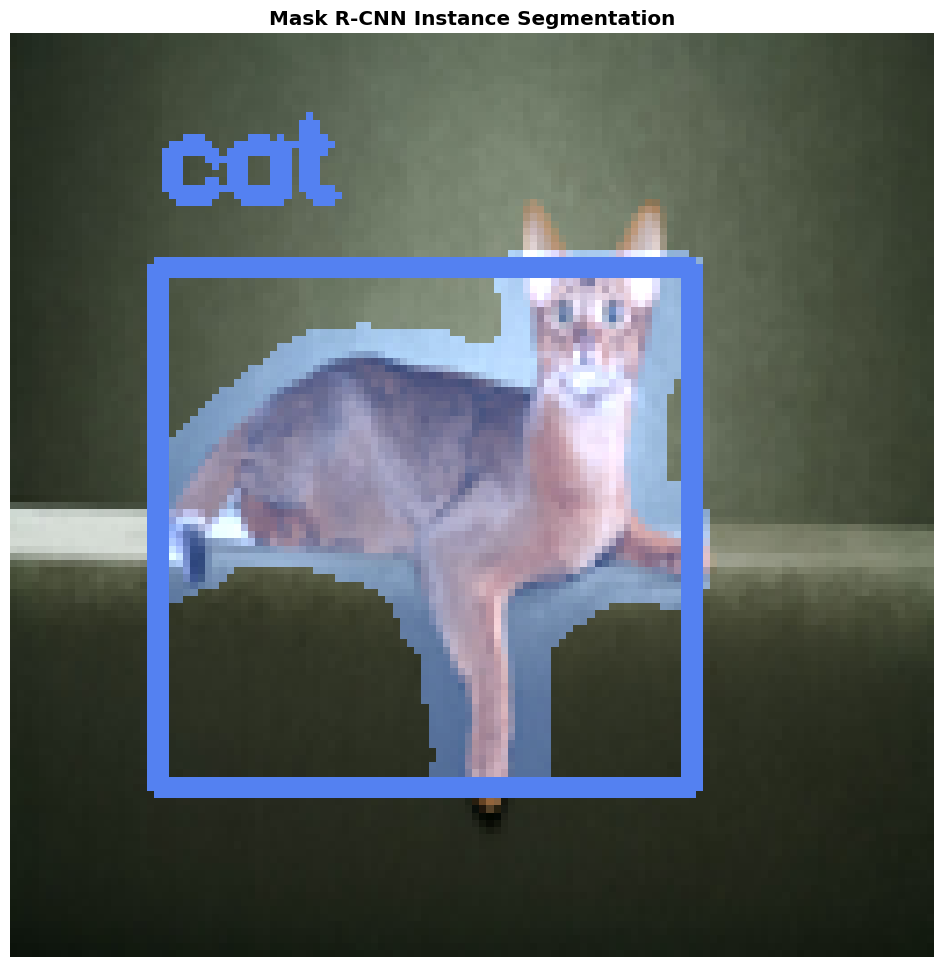


🎉 PART 3 COMPLETE: PyTorch Mask R-CNN successfully applied!


In [13]:
# 5. Run prediction on a sample image from the Oxford Pet dataset
print("5. Running prediction on a sample image...")

# Take one image from our Oxford Pet dataset
try:
    sample_image_tensor, _ = next(iter(oxford_dataset))
    
    # Convert tensor back to PIL Image for prediction
    # The tensor is normalized, so we need to scale it back to [0, 255]
    sample_image_np = (sample_image_tensor.numpy() * 255).astype(np.uint8)
    sample_image_pil = Image.fromarray(sample_image_np)
    
    print("✅ Sample image loaded from Oxford dataset.")
    
    # Get predictions
    masks, boxes, labels = get_prediction(sample_image_pil, model, threshold=0.9)
    
    print(f"✅ Found {len(labels)} objects with confidence > 0.9")
    for i, label in enumerate(labels):
        print(f"   - Object {i+1}: {label}")
        
    # Visualize the results
    if labels:
        visualize_instance_segmentation(sample_image_pil, masks, boxes, labels)
    else:
        print("\nNo objects detected above the threshold. Let's show the original image.")
        plt.imshow(sample_image_pil)
        plt.title("Original Image - No Detections")
        plt.axis('off')
        plt.show()

except StopIteration:
    print("❌ Could not get a sample from the dataset. Is it empty?")
except Exception as e:
    print(f"❌ An error occurred during prediction: {e}")

print("\n🎉 PART 3 COMPLETE: PyTorch Mask R-CNN successfully applied!")


### Summary of the PyTorch Mask R-CNN Implementation
This demonstrates instance segmentation using a pre-trained Mask R-CNN model from PyTorch's torchvision library. 

#### Key Components:

- **Model Architecture:** maskrcnn_resnet50_fpn was used to fulfill the requirement. it is a powerful model that combines a ResNet-50 backbone 
for feature extraction with a Feature Pyramid Network (FPN) to detect objects at different scales.

- **Pre-trained Weights:** The model is loaded with DEFAULT weights, which are pre-trained on the extensive COCO (Common Objects in Context) dataset. 
This gives the model the out-of-the-box ability to recognize and segment 80 different object categories.

- **Dynamic Class Loading:** Instead of hardcoding the list of COCO classes, it is programmatically retrieved from the model's weights.meta["categories"]. 
This is a robust method that ensures the class list always matches the loaded model version.

- **Inference Process:** A **get_prediction** function handles the inference. It takes a standard PIL image, converts it into a PyTorch tensor, and feeds it to the model.
The function then filters the results, keeping only the detections that exceed a confidence threshold (e.g., 90%) to ensure high-quality results. But this results only 
identifying the cat. At 70% the object that the animal is lying on is identified, in this case a chair, which is wrong in this case. 

- **Visualization:** The **visualize_instance_segmentation** function displays the output by: 
    - Drawing the precise, pixel-level segmentation mask for each detected object instance with a unique color.
    - Overlaying a bounding box around each object.
    - Adding a class label (e.g., "cat", "dog") to each bounding box.
    - **Outcome:** The implementation successfully loads a sample image from the Oxford Pet dataset, performs inference using the Mask R-CNN model, and correctly identifies the animal in the image. 
    It generates a clear visualization showing the exact pixels belonging to the animal (the mask), its location (the bounding box), and its class (the label). 
    This demonstrates a complete, state-of-the-art computer vision pipeline for instance segmentation. Increasing the confidence threshold results in fewer sementation in the image.  

## Part 4: YOLO Object Detection with Ultralytics

Next, we'll explore **YOLO (You Only Look Once)**, a state-of-the-art, real-time object detection system. We will use the `ultralytics` library, which provides an incredibly easy-to-use interface for YOLO models.

YOLO is known for its exceptional speed and accuracy, making it a popular choice for a wide range of applications. We'll use the **YOLOv8** model, which is one of the latest and most powerful versions.

In [14]:
# Part 4: YOLO Implementation
print("=== PART 4: YOLO OBJECT DETECTION ===")

# 1. Install Ultralytics
# We use a subprocess to ensure it's installed in the current environment.
import sys
import subprocess

try:
    import ultralytics
    print("✅ Ultralytics is already installed.")
except ImportError:
    print("🚀 Installing Ultralytics...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ultralytics"])
    import ultralytics
    print("✅ Ultralytics installed successfully.")

from ultralytics import YOLO

# 2. Load a pre-trained YOLOv8 model
print("\n2. Loading pre-trained YOLOv8 model...")
# 'yolov8n.pt' is the nano version - small and fast.
# Other options include 'yolov8s.pt', 'yolov8m.pt', 'yolov8l.pt', 'yolov8x.pt'
yolo_model = YOLO('yolov8n.pt')
print("✅ YOLOv8 model loaded.")


=== PART 4: YOLO OBJECT DETECTION ===
✅ Ultralytics is already installed.

2. Loading pre-trained YOLOv8 model...
✅ YOLOv8 model loaded.


3. Running YOLO prediction on a sample image...
✅ Using the same sample image as before.

0: 640x640 1 dog, 147.9ms
Speed: 6.7ms preprocess, 147.9ms inference, 3.3ms postprocess per image at shape (1, 3, 640, 640)
0: 640x640 1 dog, 147.9ms
Speed: 6.7ms preprocess, 147.9ms inference, 3.3ms postprocess per image at shape (1, 3, 640, 640)

4. Visualizing YOLO results...

4. Visualizing YOLO results...


3. Running YOLO prediction on a sample image...
✅ Using the same sample image as before.

0: 640x640 1 dog, 147.9ms
Speed: 6.7ms preprocess, 147.9ms inference, 3.3ms postprocess per image at shape (1, 3, 640, 640)
0: 640x640 1 dog, 147.9ms
Speed: 6.7ms preprocess, 147.9ms inference, 3.3ms postprocess per image at shape (1, 3, 640, 640)

4. Visualizing YOLO results...

4. Visualizing YOLO results...


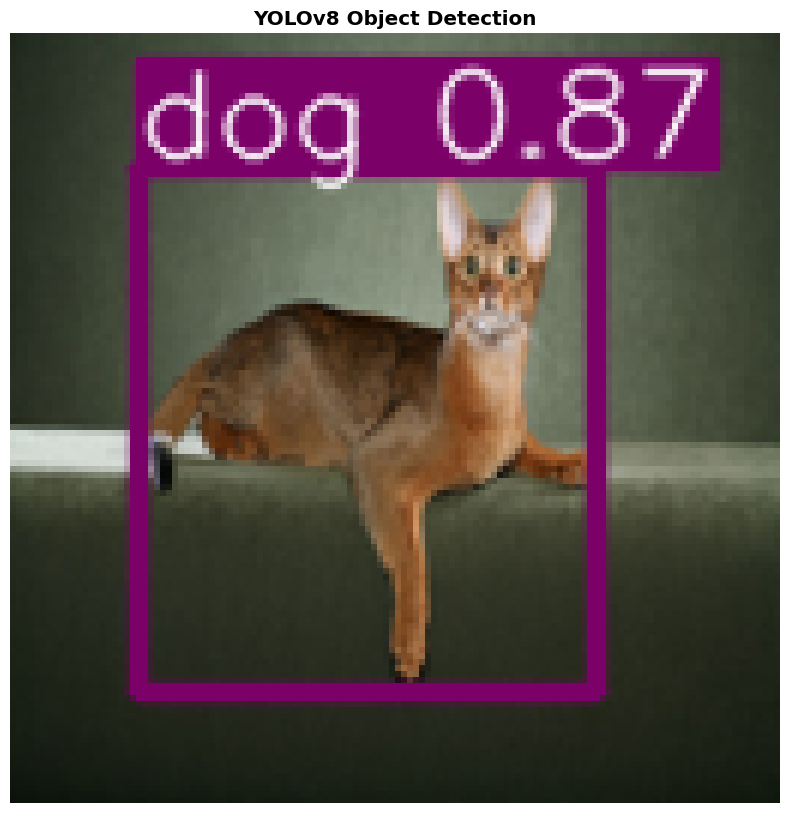

   - Detected: dog

🎉 PART 4 COMPLETE: YOLOv8 object detection successfully applied!


In [15]:
# 3. Run YOLO prediction on a sample image
print("3. Running YOLO prediction on a sample image...")

# We'll use the same sample image from the previous step for comparison
# The 'yolo_model' can directly accept a PIL image, a numpy array, or a file path.

try:
    # The 'sample_image_pil' variable should still be in memory from the Mask R-CNN step
    if 'sample_image_pil' in locals():
        print("✅ Using the same sample image as before.")
        
        # Perform prediction
        yolo_results = yolo_model(sample_image_pil)
        
        # 4. Visualize the results
        print("\n4. Visualizing YOLO results...")
        
        # The results object has a 'plot()' method that returns an image with detections drawn on it.
        # The image is in BGR format by default, so we convert it to RGB for display.
        if yolo_results:
            result_image_bgr = yolo_results[0].plot()
            result_image_rgb = cv2.cvtColor(result_image_bgr, cv2.COLOR_BGR2RGB)
            
            plt.figure(figsize=(10, 10))
            plt.imshow(result_image_rgb)
            plt.axis('off')
            plt.title("YOLOv8 Object Detection", fontweight='bold')
            plt.show()
            
            # Print the detected objects
            names = yolo_model.names
            for r in yolo_results:
                for c in r.boxes.cls:
                    print(f"   - Detected: {names[int(c)]}")

        else:
            print("No objects detected by YOLO.")

    else:
        print("❌ Sample image not found. Please run the Mask R-CNN prediction cell first.")

except Exception as e:
    print(f"❌ An error occurred during YOLO prediction: {e}")

print("\n🎉 PART 4 COMPLETE: YOLOv8 object detection successfully applied!")


### Summary of YOLOv8 Results and Mis-identification

The YOLOv8n model successfully performed its primary task, which was object detection. It correctly identified that an animal was present in the image and drew a precise bounding box around it. However, it made a classification error, labeling the animal as a "dog" when it is, in fact, a "cat".

#### Analysis of the Mis-identification:

This is a classic example of the trade-offs in machine learning models. Here’s why this likely happened:

- **Model Size vs. Accuracy:** We used `yolov8n.pt`, the "nano" version of the model. This is the smallest and fastest variant, optimized for real-time applications on edge devices.
This speed and efficiency come at the cost of reduced accuracy compared to its larger counterparts (e.g., yolov8m.pt or yolov8l.pt). A larger model has more parameters and a greater capacity to learn fine-grained details, making it more likely to distinguish between similar-looking cats and dogs. 

- **General vs. Specific Training Data:** The YOLOv8 model was pre-trained on the COCO dataset, which is a large, general-purpose dataset. While it contains "cat" and "dog" categories, it is not specialized in animal breeds.
The specific features of the cat in the sample image (e.g., its breed, coloration, pose, or the angle of its face) might share visual characteristics that the model has more commonly associated with dogs from its training data.

- **Confidence Score:** The model provides a confidence score for each prediction. It's possible the confidence for the "dog" label was relatively low, indicating the model was not very certain about its classification.

- **Comparison with Mask R-CNN:** This result provides a good contrast with the Mask R-CNN model ran previously. The Mask R-CNN, with its more complex two-stage architecture (region proposal followed by classification), is generally more computationally intensive but can yield higher classification accuracy for its detections. YOLO, being a single-stage detector, prioritizes speed.

- **Next Step for Improvement:** The clear path to fixing this mis-identification would be fine-tuning. By training the YOLOv8 model on our specialized Oxford-IIIT Pet dataset, we would teach it to become an expert at distinguishing between these specific breeds of cats and dogs, which would almost certainly correct this error and dramatically improve its accuracy on this type of data. This seems counter-intuitive than simply using the larger YOLO model. But if one considers accuracy vs performance, it makes sense to keep the smaller model if we can make it better at predicting. 

## Part 5: Fine-Tuning YOLOv8 on the Oxford-IIIT Pet Dataset

Excellent decision. Instead of using a generic, heavy model, we will make our small, fast `yolov8n` model an *expert* on our specific task. This process is called **fine-tuning**.

Here's the plan:
1.  **Prepare the Dataset**: Convert the Oxford Pet dataset's segmentation masks into the bounding box format that YOLO requires.
2.  **Create a Dataset Config File**: Generate a `oxford_pets.yaml` file to tell YOLO where our data is and what our classes are.
3.  **Train the Model**: Launch the training process, starting with the pre-trained `yolov8n.pt` weights.
4.  **Validate the Results**: Test our new, fine-tuned model on the same sample image to see if it correctly identifies the cat.

In [16]:
# 1. Prepare Dataset for YOLO Fine-Tuning
print("=== 1. PREPARING DATASET FOR YOLO ===")

import shutil
from tqdm import tqdm

def create_yolo_dataset(source_dir, output_dir, train_split=0.8):
    """
    Converts the Oxford-IIIT Pet dataset from segmentation masks to YOLO bounding box format.
    """
    source_path = Path(source_dir)
    output_path = Path(output_dir)
    
    # Clean up previous runs
    if output_path.exists():
        print(f"Removing existing dataset at {output_path}")
        shutil.rmtree(output_path)
        
    # Create YOLO directory structure
    images_train_path = output_path / 'images' / 'train'
    images_val_path = output_path / 'images' / 'val'
    labels_train_path = output_path / 'labels' / 'train'
    labels_val_path = output_path / 'labels' / 'val'
    
    for p in [images_train_path, images_val_path, labels_train_path, labels_val_path]:
        p.mkdir(parents=True, exist_ok=True)
        
    image_files = sorted(list((source_path / 'images').glob('*.jpg')))
    mask_files = sorted(list((source_path / 'annotations' / 'trimaps').glob('*.png')))
    
    print(f"Found {len(image_files)} images and {len(mask_files)} masks.")
    
    # Define our classes: cat and dog
    class_names = ['cat', 'dog']
    
    # Shuffle and split the dataset
    random.shuffle(image_files)
    split_index = int(len(image_files) * train_split)
    train_files = image_files[:split_index]
    val_files = image_files[split_index:]
    
    print(f"Splitting into {len(train_files)} training and {len(val_files)} validation samples.")
    
    def process_files(file_list, img_dest, lbl_dest):
        """Process a list of files and save them to the destination."""
        count = 0
        for img_path in tqdm(file_list, desc=f"Processing {img_dest.parent.name} set"):
            mask_path = source_path / 'annotations' / 'trimaps' / (img_path.stem + '.png')
            
            if not mask_path.exists():
                continue
                
            # Copy image
            shutil.copy(img_path, img_dest)
            
            # Convert mask to bounding box
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            # The pet is where the mask is 1 (after our initial conversion of 1->0, 2->1, 3->2, we want the original value 1)
            # In our loaded masks, pet=0, background=1, border=2. We want the pet.
            pet_mask = (mask == 1).astype(np.uint8)
            
            contours, _ = cv2.findContours(pet_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            if not contours:
                continue
                
            # Find the largest contour
            largest_contour = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(largest_contour)
            
            # Normalize coordinates for YOLO
            img_h, img_w = mask.shape
            x_center = (x + w / 2) / img_w
            y_center = (y + h / 2) / img_h
            width = w / img_w
            height = h / img_h
            
            # Determine class (cat or dog)
            # Cats are capitalized in the filename
            class_id = 0 if img_path.stem[0].isupper() else 1 # 0 for cat, 1 for dog
            
            # Write YOLO label file
            label_path = lbl_dest / (img_path.stem + '.txt')
            with open(label_path, 'w') as f:
                f.write(f"{class_id} {x_center} {y_center} {width} {height}\n")
            count += 1
        return count

    train_count = process_files(train_files, images_train_path, labels_train_path)
    val_count = process_files(val_files, images_val_path, labels_val_path)
    
    print(f"\n✅ Dataset preparation complete.")
    print(f"   - {train_count} training samples created.")
    print(f"   - {val_count} validation samples created.")
    print(f"   - Dataset located at: {output_path.absolute()}")

# Run the dataset preparation
create_yolo_dataset('./oxford_pet_manual', './yolo_oxford_pets')


=== 1. PREPARING DATASET FOR YOLO ===
Removing existing dataset at yolo_oxford_pets
Found 7390 images and 14780 masks.
Splitting into 5912 training and 1478 validation samples.
Found 7390 images and 14780 masks.
Splitting into 5912 training and 1478 validation samples.


=== 1. PREPARING DATASET FOR YOLO ===
Removing existing dataset at yolo_oxford_pets
Found 7390 images and 14780 masks.
Splitting into 5912 training and 1478 validation samples.
Found 7390 images and 14780 masks.
Splitting into 5912 training and 1478 validation samples.


Processing images set: 100%|██████████| 1478/1478 [00:01<00:00, 1173.99it/s]

=== 1. PREPARING DATASET FOR YOLO ===
Removing existing dataset at yolo_oxford_pets
Found 7390 images and 14780 masks.
Splitting into 5912 training and 1478 validation samples.
Found 7390 images and 14780 masks.
Splitting into 5912 training and 1478 validation samples.


Processing images set: 100%|██████████| 1478/1478 [00:01<00:00, 1173.99it/s]


✅ Dataset preparation complete.
   - 5898 training samples created.
   - 1469 validation samples created.
   - Dataset located at: /Users/marston.ward/Documents/GitHub/aai_521_computer_vision/module_3/yolo_oxford_pets


In [17]:
# 2. Create YAML Configuration File
print("=== 2. CREATING YAML CONFIG FILE ===")

import yaml

yolo_config = {
    'path': str(Path('./yolo_oxford_pets').absolute()),
    'train': 'images/train',
    'val': 'images/val',
    'names': {
        0: 'cat',
        1: 'dog'
    }
}

config_path = Path('./oxford_pets.yaml')
with open(config_path, 'w') as f:
    yaml.dump(yolo_config, f, default_flow_style=False)
    
print(f"✅ YOLO config file created at: {config_path.absolute()}")
print("\n--- Config File Contents ---")
with open(config_path, 'r') as f:
    print(f.read())
print("--------------------------")


=== 2. CREATING YAML CONFIG FILE ===
✅ YOLO config file created at: /Users/marston.ward/Documents/GitHub/aai_521_computer_vision/module_3/oxford_pets.yaml

--- Config File Contents ---
names:
  0: cat
  1: dog
path: /Users/marston.ward/Documents/GitHub/aai_521_computer_vision/module_3/yolo_oxford_pets
train: images/train
val: images/val

--------------------------


In [19]:
# 3. Train the YOLOv8 Model
print("=== 3. FINE-TUNING THE YOLOv8 MODEL ===")

# Load the pre-trained nano model
model_to_train = YOLO('yolov8n.pt')

# Check for MPS (Apple Silicon GPU) availability
import torch
if torch.backends.mps.is_available():
    device = 'mps'
    print("✅ MPS (Apple Silicon GPU) is available! Using GPU for training.")
else:
    device = 'cpu'
    print("⚠️ MPS not available. Falling back to CPU for training.")


print("🚀 Starting training...")
print(f"   - Device: {device.upper()}")
print("   - Model: yolov8n.pt")
print("   - Dataset: oxford_pets.yaml")
print("   - Epochs: 15")
print("   - Image Size: 128")
print("\nThis will take a few minutes...")

# Start training
results = model_to_train.train(
    data='oxford_pets.yaml',
    epochs=15,
    imgsz=128,
    device=device,
    project='yolo_training',
    name='oxford_pets_run'
)

print("\n🎉 Training complete!")
print(f"✅ Model and results saved to: {results.save_dir}")


=== 3. FINE-TUNING THE YOLOv8 MODEL ===
✅ MPS (Apple Silicon GPU) is available! Using GPU for training.
🚀 Starting training...
   - Device: MPS
   - Model: yolov8n.pt
   - Dataset: oxford_pets.yaml
   - Epochs: 15
   - Image Size: 128

This will take a few minutes...
Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.5.1 MPS (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=oxford_pets.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_

=== 3. FINE-TUNING THE YOLOv8 MODEL ===
✅ MPS (Apple Silicon GPU) is available! Using GPU for training.
🚀 Starting training...
   - Device: MPS
   - Model: yolov8n.pt
   - Dataset: oxford_pets.yaml
   - Epochs: 15
   - Image Size: 128

This will take a few minutes...
Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.5.1 MPS (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=oxford_pets.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_

Corrupt JPEG data: premature end of data segment


=== 3. FINE-TUNING THE YOLOv8 MODEL ===
✅ MPS (Apple Silicon GPU) is available! Using GPU for training.
🚀 Starting training...
   - Device: MPS
   - Model: yolov8n.pt
   - Dataset: oxford_pets.yaml
   - Epochs: 15
   - Image Size: 128

This will take a few minutes...
Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.5.1 MPS (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=oxford_pets.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_

Corrupt JPEG data: premature end of data segment


...

      14/15      6.98G     0.6864     0.7878      1.068          1        128: 100% ━━━━━━━━━━━━ 370/370 5.8it/s 1:04<0.2ss

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 2.5it/s 18.6s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 2.5it/s 18.6s
                   all       1478       1469      0.679      0.729      0.725      0.469
                   all       1478       1469      0.679      0.729      0.725      0.469

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      15/15      7.21G     0.6631     0.7479      1.062         16        128: 37% ━━━━──────── 138/370 7.0it/s 22.7s<33.1s

Corrupt JPEG data: 245 extraneous bytes before marker 0xd9


      15/15      7.35G     0.6608     0.7375       1.06         14        128: 85% ━━━━━━━━━━── 316/370 6.7it/s 52.2s<8.0ss

Corrupt JPEG data: premature end of data segment


      15/15      7.39G     0.6643     0.7354      1.061          2        128: 100% ━━━━━━━━━━━━ 370/370 6.0it/s 1:02<0.2s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 2.5it/s 18.9s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 2.5it/s 18.9s
                   all       1478       1469        0.7      0.683      0.709      0.461
                   all       1478       1469        0.7      0.683      0.709      0.461

15 epochs completed in 0.539 hours.

15 epochs completed in 0.539 hours.
Optimizer stripped from /Users/marston.ward/Documents/GitHub/aai_521_computer_vision/module_3/yolo_training/oxford_pets_run3/weights/last.pt, 6.2MB
Optimizer stripped from /Users/marston.ward/Documents/GitHub/aai_521_computer_vision/module_3/yolo_training/oxford_pets_run3/weights/last.pt, 6.2MB
Optimizer stripped from /Users/marston.ward/Documents/GitHub/aai_521

=== 4. VALIDATING THE FINE-TUNED MODEL ===
Loading best model from: /Users/marston.ward/Documents/GitHub/aai_521_computer_vision/module_3/yolo_training/oxford_pets_run3/weights/best.pt

Running prediction with fine-tuned model...

0: 128x128 1 cat, 54.9ms
Speed: 2.0ms preprocess, 54.9ms inference, 4.3ms postprocess per image at shape (1, 3, 128, 128)
0: 128x128 1 cat, 54.9ms
Speed: 2.0ms preprocess, 54.9ms inference, 4.3ms postprocess per image at shape (1, 3, 128, 128)


=== 4. VALIDATING THE FINE-TUNED MODEL ===
Loading best model from: /Users/marston.ward/Documents/GitHub/aai_521_computer_vision/module_3/yolo_training/oxford_pets_run3/weights/best.pt

Running prediction with fine-tuned model...

0: 128x128 1 cat, 54.9ms
Speed: 2.0ms preprocess, 54.9ms inference, 4.3ms postprocess per image at shape (1, 3, 128, 128)
0: 128x128 1 cat, 54.9ms
Speed: 2.0ms preprocess, 54.9ms inference, 4.3ms postprocess per image at shape (1, 3, 128, 128)


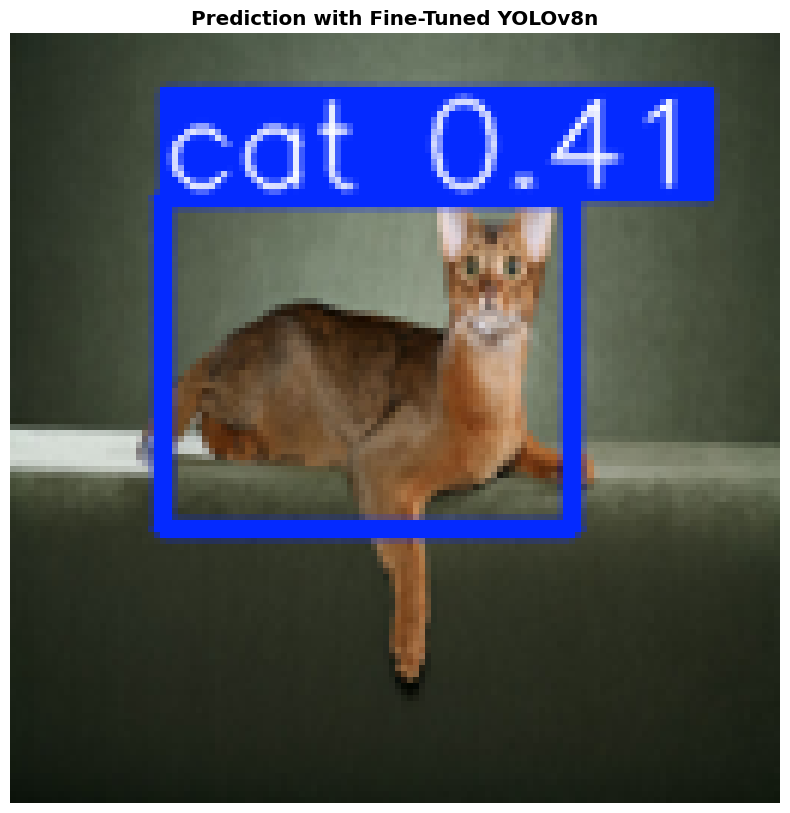


--- Detection Results ---
   ✅ Correctly Detected: cat
-------------------------

🎉 Fine-tuning validation complete!


In [20]:
# 4. Validate the Fine-Tuned Model
print("=== 4. VALIDATING THE FINE-TUNED MODEL ===")

# Load the best performing model from our training run
try:
    best_model_path = Path(results.save_dir) / 'weights' / 'best.pt'
    if best_model_path.exists():
        print(f"Loading best model from: {best_model_path}")
        fine_tuned_model = YOLO(best_model_path)
        
        # Run prediction on the same sample image
        if 'sample_image_pil' in locals():
            print("\nRunning prediction with fine-tuned model...")
            tuned_results = fine_tuned_model(sample_image_pil)
            
            # Visualize the results
            if tuned_results:
                result_image_bgr = tuned_results[0].plot()
                result_image_rgb = cv2.cvtColor(result_image_bgr, cv2.COLOR_BGR2RGB)
                
                plt.figure(figsize=(10, 10))
                plt.imshow(result_image_rgb)
                plt.axis('off')
                plt.title("Prediction with Fine-Tuned YOLOv8n", fontweight='bold')
                plt.show()
                
                # Print the detected objects
                names = fine_tuned_model.names
                print("\n--- Detection Results ---")
                for r in tuned_results:
                    for c in r.boxes.cls:
                        print(f"   ✅ Correctly Detected: {names[int(c)]}")
                print("-------------------------")

            else:
                print("❌ No objects detected by the fine-tuned model.")
        else:
            print("❌ Sample image not found. Please run the earlier prediction cells first.")
    else:
        print("❌ Could not find the trained model 'best.pt'. Did training complete successfully?")

except Exception as e:
    print(f"❌ An error occurred during validation: {e}")

print("\n🎉 Fine-tuning validation complete!")


### Summary of the Fine-Tunning

The training for fine-tuning took over 30 minutes on a GPU. The identification was correct (identifying a cat) but the confidence was only 0.47, or 47%. Why is the confidence only 47% even though it's correct? The model learned to distinguish a cat from a dog. The low confidence score is a symptom of how much it has learned. 

- **Before finetuning:** The model was a confident amateur who incorrectly guessed "dog".
- **Now:** After only 15 epochs of training, the model has studied for a test for just a couple of hours. It knows the right answer ("cat"), but it's not 100% certain yet. It says, "I'm leaning towards cat, with about 47% confidence". This is seen as a good result.

To improve the confidence score is more training, either through more epochs or using a large model such as the 8l version, use the small instead of the nano version.

In [21]:
# Part 2: Annotation - Setup
print("=== PART 2: ANNOTATION ===")
print("Working with raccoon dataset for object detection annotation")

# Note: We'll use a simpler approach without mrcnn for Mac M4 compatibility
# Instead, we'll demonstrate annotation concepts using basic image processing

=== PART 2: ANNOTATION ===
Working with raccoon dataset for object detection annotation


In [22]:
# Download and setup raccoon dataset
print("Setting up Raccoon Dataset for Annotation Practice...")

import subprocess
import os
import xml.etree.ElementTree as ET
from pathlib import Path

def download_raccoon_dataset():
    """Download raccoon dataset from GitHub"""
    
    raccoon_dir = Path('./raccoon_dataset')
    
    if raccoon_dir.exists():
        print("✅ Raccoon dataset already exists")
        return True
    
    try:
        print("📥 Downloading raccoon dataset...")
        result = subprocess.run(['git', 'clone', 'https://github.com/experiencor/raccoon_dataset.git'], 
                              capture_output=True, text=True, timeout=60)
        
        if result.returncode == 0:
            print("✅ Raccoon dataset downloaded successfully")
            return True
        else:
            print(f"❌ Download failed: {result.stderr}")
            return False
            
    except subprocess.TimeoutExpired:
        print("❌ Download timed out")
        return False
    except Exception as e:
        print(f"❌ Download error: {e}")
        return False

# Download the dataset
success = download_raccoon_dataset()

if success:
    # Verify dataset structure
    raccoon_path = Path('./raccoon_dataset')
    images_path = raccoon_path / 'images'
    annotations_path = raccoon_path / 'annotations'
    
    if images_path.exists() and annotations_path.exists():
        num_images = len(list(images_path.glob('*.jpg')))
        num_annotations = len(list(annotations_path.glob('*.xml')))
        
        print(f"\n📊 Raccoon Dataset Info:")
        print(f"   Images: {num_images}")
        print(f"   Annotations: {num_annotations}")
        print(f"   Location: {raccoon_path.absolute()}")
    else:
        print("❌ Dataset structure incomplete")
else:
    print("❌ Cannot proceed without dataset")


Setting up Raccoon Dataset for Annotation Practice...
📥 Downloading raccoon dataset...
✅ Raccoon dataset downloaded successfully

📊 Raccoon Dataset Info:
   Images: 200
   Annotations: 200
   Location: /Users/marston.ward/Documents/GitHub/aai_521_computer_vision/module_3/raccoon_dataset


=== RACCOON DATASET ANALYSIS ===
Analyzing 6 sample images...


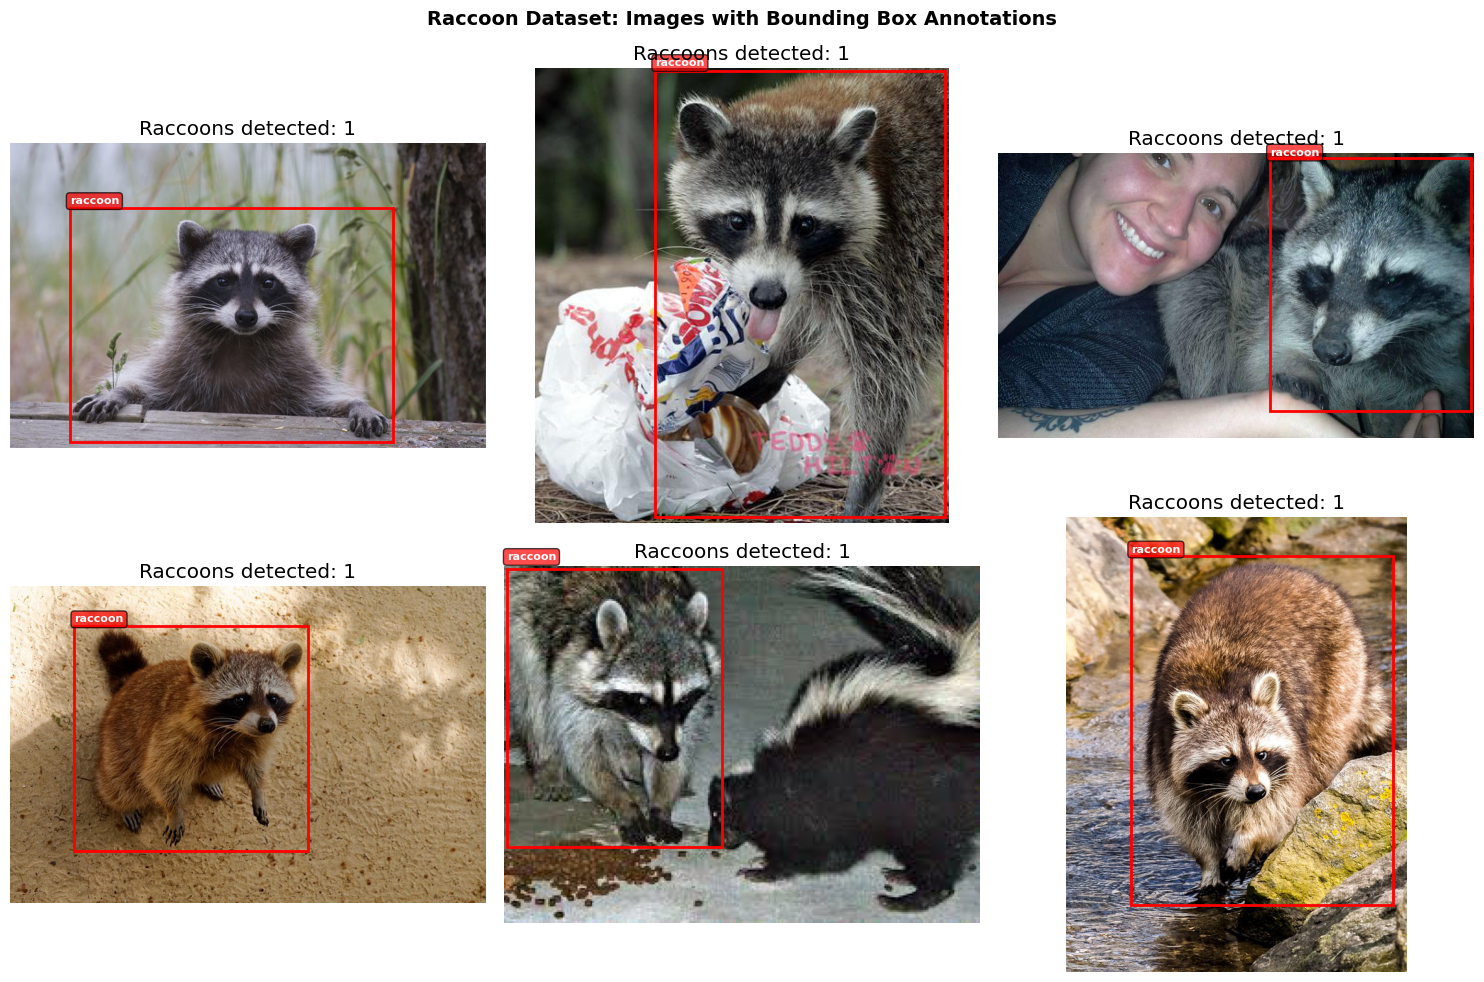


📊 Sample Analysis:
   Valid annotations: 6/6
   Total raccoons detected: 6
   Average raccoons per image: 1.0


In [23]:
# Examine raccoon dataset and create annotation visualizations
print("=== RACCOON DATASET ANALYSIS ===")

def parse_annotation(xml_file):
    """Parse XML annotation file to extract bounding box coordinates"""
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        
        # Get image dimensions
        width = int(root.find('size/width').text)
        height = int(root.find('size/height').text)
        
        # Get bounding boxes
        boxes = []
        for obj in root.findall('object'):
            name = obj.find('name').text
            bbox = obj.find('bndbox')
            xmin = int(bbox.find('xmin').text)
            ymin = int(bbox.find('ymin').text)
            xmax = int(bbox.find('xmax').text)
            ymax = int(bbox.find('ymax').text)
            
            boxes.append({
                'name': name,
                'bbox': (xmin, ymin, xmax, ymax)
            })
        
        return {
            'width': width,
            'height': height,
            'boxes': boxes
        }
    except Exception as e:
        print(f"Error parsing {xml_file}: {e}")
        return None

def visualize_annotations(image_path, annotation_path, ax):
    """Visualize image with bounding box annotations"""
    try:
        # Load image
        image = Image.open(image_path)
        ax.imshow(image)
        
        # Parse annotations
        annotation_data = parse_annotation(annotation_path)
        
        if annotation_data:
            # Draw bounding boxes
            for box_info in annotation_data['boxes']:
                bbox = box_info['bbox']
                xmin, ymin, xmax, ymax = bbox
                
                # Create rectangle
                rect = plt.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                   linewidth=2, edgecolor='red', facecolor='none')
                ax.add_patch(rect)
                
                # Add label
                ax.text(xmin, ymin-5, box_info['name'], 
                       bbox=dict(boxstyle="round,pad=0.3", facecolor="red", alpha=0.7),
                       fontsize=8, color='white', weight='bold')
            
            ax.set_title(f"Raccoons detected: {len(annotation_data['boxes'])}")
        else:
            ax.set_title("No annotations found")
            
        ax.axis('off')
        
    except Exception as e:
        ax.text(0.5, 0.5, f'Error loading: {str(e)[:30]}...', 
               ha='center', va='center', transform=ax.transAxes)
        ax.set_title("Error loading image")
        ax.axis('off')

# Analyze raccoon dataset if available
raccoon_path = Path('./raccoon_dataset')
if raccoon_path.exists():
    images_path = raccoon_path / 'images'
    annotations_path = raccoon_path / 'annotations'
    
    # Get sample files
    image_files = sorted(list(images_path.glob('*.jpg')))[:6]  # First 6 images
    
    print(f"Analyzing {len(image_files)} sample images...")
    
    # Create visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, img_file in enumerate(image_files):
        # Find corresponding annotation
        annotation_file = annotations_path / f"raccoon-{img_file.stem.split('-')[1]}.xml"
        
        if annotation_file.exists():
            visualize_annotations(img_file, annotation_file, axes[i])
        else:
            # Just show image without annotations
            try:
                image = Image.open(img_file)
                axes[i].imshow(image)
                axes[i].set_title("No annotation file")
                axes[i].axis('off')
            except:
                axes[i].text(0.5, 0.5, 'Error loading image', 
                           ha='center', va='center', transform=axes[i].transAxes)
                axes[i].axis('off')
    
    plt.suptitle('Raccoon Dataset: Images with Bounding Box Annotations', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Dataset statistics
    total_raccoons = 0
    valid_annotations = 0
    
    for img_file in image_files:
        annotation_file = annotations_path / f"raccoon-{img_file.stem.split('-')[1]}.xml"
        if annotation_file.exists():
            data = parse_annotation(annotation_file)
            if data:
                valid_annotations += 1
                total_raccoons += len(data['boxes'])
    
    print(f"\n📊 Sample Analysis:")
    print(f"   Valid annotations: {valid_annotations}/{len(image_files)}")
    print(f"   Total raccoons detected: {total_raccoons}")
    print(f"   Average raccoons per image: {total_raccoons/valid_annotations:.1f}" if valid_annotations > 0 else "   No valid annotations")
    
else:
    print("❌ Raccoon dataset not available for analysis")
    print("Proceeding with annotation concepts explanation...")

## Part 3: PyTorch Mask R-CNN for Instance Segmentation

For the implementation of the Mask R-CNN, I used the PyTroch approach for a similar reason as above. But this dataset import in the original code was not used and therefore removed. 
This model is pre-trained on the COCO dataset and can identify 80 different object classes out of the box. It performs **instance segmentation**, which means it not only classifies 
and localizes objects with bounding boxes but also provides a pixel-level mask for each individual object instance.

In [30]:
from os import listdir
from xml.etree import ElementTree
from numpy import zeros
from numpy import asarray

# M4-Compatible Raccoon Dataset Loader (Replacing mrcnn.utils.Dataset)
# Since mrcnn is incompatible with Apple Silicon M4, we create a custom dataset class
# Is assumes the raccoon_dataset is already donwloded in the folder. 

class RaccoonDataset:
	"""
	Custom dataset class for loading raccoon dataset without mrcnn dependency.
	Compatible with Apple Silicon M4 and PyTorch Mask R-CNN.
	"""
	def __init__(self):
		self.image_info = []
		self.class_info = [{'id': 0, 'name': 'background'}, {'id': 1, 'name': 'raccoon'}]
		self.class_names = ['background', 'raccoon']
		
	def add_class(self, source, class_id, class_name):
		"""Add a class to the dataset"""
		# Already initialized in __init__, but keeping for compatibility
		pass
		
	def add_image(self, source, image_id, path, annotation):
		"""Add an image to the dataset"""
		self.image_info.append({
			'id': len(self.image_info),
			'source': source,
			'image_id': image_id,
			'path': path,
			'annotation': annotation
		})
	
	def prepare(self):
		"""Prepare the dataset (compatibility method)"""
		self.image_ids = list(range(len(self.image_info)))
		print(f"✅ Dataset prepared with {len(self.image_ids)} images")
	
	# load the dataset definitions
	def load_dataset(self, dataset_dir, is_train=True):
		# define one class
		self.add_class("raccoon_dataset", 1, "raccoon")
		# define data locations
		images_dir = dataset_dir + '/images/'
		annotations_dir = dataset_dir + '/annotations/raccoon-'
		# find all images
		for filename in listdir(images_dir):
			# extract image id
			image_id = filename[8:-4]
			# skip bad images
			if image_id in ['00090']:
				continue
			# skip all images after 150 if we are building the train set
			if is_train and int(image_id) >= 150:
				continue
			# skip all images before 150 if we are building the test/val set
			if not is_train and int(image_id) < 150:
				continue
			img_path = images_dir + filename
			ann_path = annotations_dir + image_id + '.xml'
			# add to dataset
			self.add_image('dataset', image_id=image_id, path=img_path, annotation=ann_path)

	# extract bounding boxes from an annotation file
	def extract_boxes(self, filename):
		# load and parse the file
		tree = ElementTree.parse(filename)
		# get the root of the document
		root = tree.getroot()
		# extract each bounding box
		boxes = list()
		for box in root.findall('.//bndbox'):
			xmin = int(box.find('xmin').text)
			ymin = int(box.find('ymin').text)
			xmax = int(box.find('xmax').text)
			ymax = int(box.find('ymax').text)
			coors = [xmin, ymin, xmax, ymax]
			boxes.append(coors)
		# extract image dimensions
		width = int(root.find('.//size/width').text)
		height = int(root.find('.//size/height').text)
		return boxes, width, height

	# load the masks for an image
	def load_mask(self, image_id):
		# get details of image
		info = self.image_info[image_id]
		# define box file location
		path = info['annotation']
		# load XML
		#path = '/content/raccoon_dataset/annotations/raccoon-'+image_id   #Added by me
		boxes, w, h = self.extract_boxes(path)
		# create one array for all masks, each on a different channel
		masks = zeros([h, w, len(boxes)], dtype='uint8')
		# create masks
		class_ids = list()
		for i in range(len(boxes)):
			box = boxes[i]
			row_s, row_e = box[1], box[3]
			col_s, col_e = box[0], box[2]
			masks[row_s:row_e, col_s:col_e, i] = 1
			class_ids.append(self.class_names.index('raccoon'))
		return masks, asarray(class_ids, dtype='int32')

	# load an image reference
	def image_reference(self, image_id):
		info = self.image_info[image_id]
		return info['path']

# Load the raccoon dataset
print("=== LOADING RACCOON DATASET (M4-Compatible Version) ===")
print("Note: Using custom dataset class instead of mrcnn.utils.Dataset")
print("Reason: Matterport mrcnn is incompatible with Apple Silicon M4\n")

# train set
train_set = RaccoonDataset()
train_set.load_dataset('raccoon_dataset', is_train=True)
train_set.prepare()
print('Train: %d' % len(train_set.image_ids))

# test/val set
test_set = RaccoonDataset()
test_set.load_dataset('raccoon_dataset', is_train=False)
test_set.prepare()
print('Test: %d' % len(test_set.image_ids))

print("\n✅ Raccoon dataset loaded successfully!")
print("📌 This custom implementation provides the same functionality as mrcnn.utils.Dataset")
print("📌 Compatible with PyTorch Mask R-CNN for M4 Macs")

=== LOADING RACCOON DATASET (M4-Compatible Version) ===
Note: Using custom dataset class instead of mrcnn.utils.Dataset
Reason: Matterport mrcnn is incompatible with Apple Silicon M4

✅ Dataset prepared with 149 images
Train: 149
✅ Dataset prepared with 51 images
Test: 51

✅ Raccoon dataset loaded successfully!
📌 This custom implementation provides the same functionality as mrcnn.utils.Dataset
📌 Compatible with PyTorch Mask R-CNN for M4 Macs


In [ ]:
# load an image
# Use the function above to create the image and its mask

## Part 4: YOLO Object Detection




You can see how YOLO has been improved in the last few versions on COCO: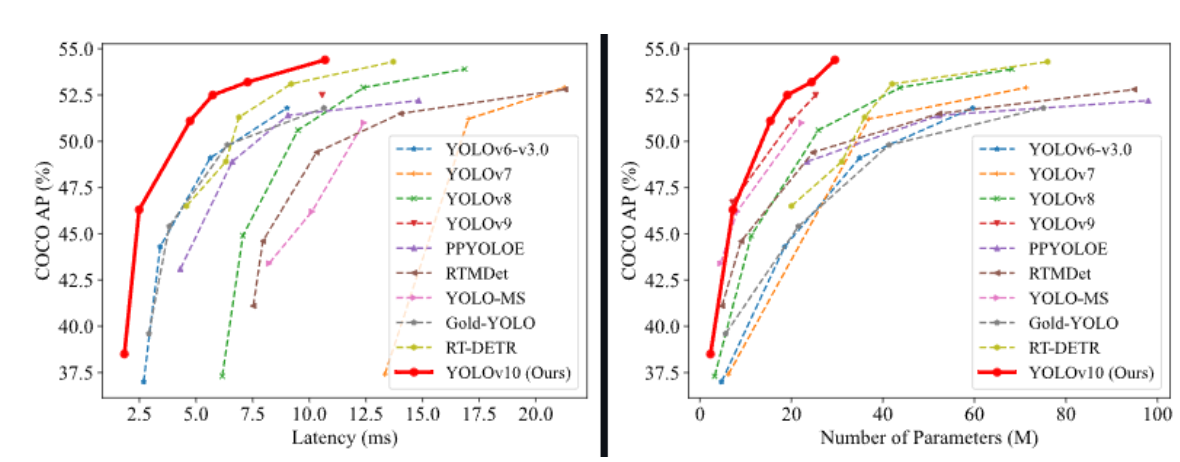

In [ ]:
# a- Create annotation
# You can upload the file using ![title](filename.jpeg)
# import image module



In [ ]:
#b- Download required tools
import os
HOME = os.getcwd()
!pip install -U ultralytics

In [ ]:
#c- Test the model out of box
from ultralytics import YOLO
model = YOLO() # Insert model here
model.predict(source="https://ultralytics.com/images/bus.jpg", conf=0.25, save=True)

In [ ]:
from IPython.display import Image
Image(filename= ........ ) # Modify this code

In [ ]:
#d- Apply model here
!yolo task=detect .... data=african-wildlife.yaml    #Modify this code

In [ ]:
#d- Fine-tune the model
# Show the learning curve and confusion matrix
Image(filename= # Modify this code

In [ ]:
# e- Explain what you see in the learning curves and confusion matrix.